In [24]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [25]:
path = "../../data/raw/playground-series-s6e1/train.csv"
df = pd.read_csv(path)

In [26]:
df.sample(10)

,id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
435177,435177,24,male,b.sc,5.93,51.8,yes,4.4,poor,online videos,medium,easy,46.0
365676,365676,22,female,bba,0.67,66.5,yes,4.1,good,online videos,high,moderate,34.7
114332,114332,17,female,bca,6.59,58.4,yes,4.5,good,self-study,low,moderate,69.3
477718,477718,20,other,b.tech,0.78,98.1,yes,9.3,good,coaching,low,hard,68.1
280697,280697,20,male,bca,1.75,70.0,yes,9.9,average,coaching,high,moderate,58.8
311404,311404,17,male,b.tech,5.81,69.8,yes,5.8,good,online videos,medium,moderate,84.1
27375,27375,19,female,b.sc,3.24,66.1,no,9.5,good,group study,medium,moderate,67.2
256712,256712,17,other,b.tech,0.09,49.8,yes,5.3,poor,mixed,low,easy,44.6
288993,288993,21,other,b.sc,1.87,99.4,no,9.4,good,group study,medium,easy,73.0
63902,63902,18,male,bba,1.77,52.4,yes,6.6,good,self-study,low,moderate,49.9


In [27]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                630000 non-null  int64  
 1   age               630000 non-null  int64  
 2   gender            630000 non-null  object 
 3   course            630000 non-null  object 
 4   study_hours       630000 non-null  float64
 5   class_attendance  630000 non-null  float64
 6   internet_access   630000 non-null  object 
 7   sleep_hours       630000 non-null  float64
 8   sleep_quality     630000 non-null  object 
 9   study_method      630000 non-null  object 
 10  facility_rating   630000 non-null  object 
 11  exam_difficulty   630000 non-null  object 
 12  exam_score        630000 non-null  float64
dtypes: float64(4), int64(2), object(7)
memory usage: 62.5+ MB


,id,age,study_hours,class_attendance,sleep_hours,exam_score
count,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000
mean,314999.500000,20.545821,4.002337,71.987261,7.072758,62.506672
std,181865.479132,2.260238,2.359880,17.430098,1.744811,18.916884
min,0.000000,17.000000,0.080000,40.600000,4.100000,19.599000
25%,157499.750000,19.000000,1.970000,57.000000,5.600000,48.800000
50%,314999.500000,21.000000,4.000000,72.600000,7.100000,62.600000
75%,472499.250000,23.000000,6.050000,87.200000,8.600000,76.300000
max,629999.000000,24.000000,7.910000,99.400000,9.900000,100.000000


In [28]:
df.isna().sum()

id                  0
age                 0
gender              0
course              0
study_hours         0
class_attendance    0
internet_access     0
sleep_hours         0
sleep_quality       0
study_method        0
facility_rating     0
exam_difficulty     0
exam_score          0
dtype: int64

In [29]:
df = df.drop(columns=["id"])

In [30]:
non_numerical = df.select_dtypes(exclude=np.number)

In [31]:
non_numerical.columns

Index(['gender', 'course', 'internet_access', 'sleep_quality', 'study_method',
       'facility_rating', 'exam_difficulty'],
      dtype='object')

In [32]:
for col in non_numerical.columns:
    pct = non_numerical[col].value_counts(normalize=True, dropna=False).mul(100).round(2)
    print(f"--- {col} ---")
    print(pct.sort_values(ascending=False).to_string())
    print()

--- gender ---
gender
other     33.51
male      33.43
female    33.07

--- course ---
course
b.tech     20.83
b.sc       17.71
b.com      17.61
bca        14.08
bba        12.01
ba          9.84
diploma     7.92

--- internet_access ---
internet_access
yes    91.97
no      8.03

--- sleep_quality ---
sleep_quality
poor       33.92
good       33.82
average    32.26

--- study_method ---
study_method
coaching         20.90
self-study       20.81
mixed            19.54
group study      19.53
online videos    19.22

--- facility_rating ---
facility_rating
medium    33.98
low       33.71
high      32.31

--- exam_difficulty ---
exam_difficulty
moderate    56.19
easy        28.02
hard        15.79



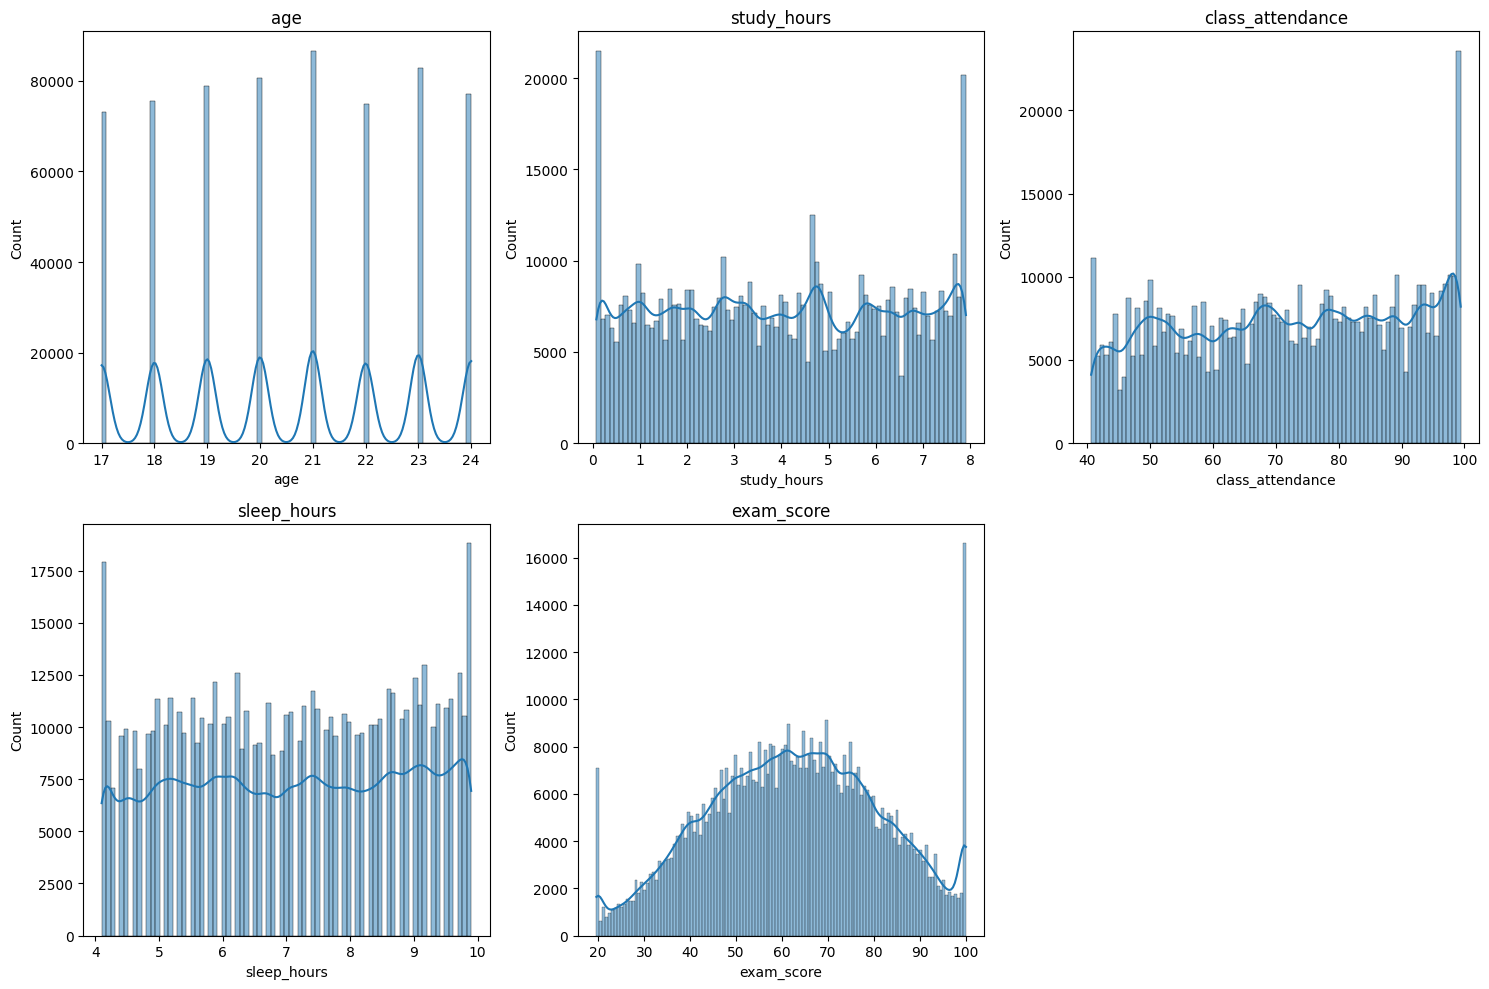

In [33]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns
n_cols = len(numeric_cols)

# Calculate grid dimensions
n_rows = (n_cols + 2) // 3  # 3 columns per row
n_plot_cols = min(n_cols, 3)

fig, axes = plt.subplots(n_rows, n_plot_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten() if n_cols > 1 else [axes]

for idx, col in enumerate(numeric_cols):
    sns.histplot(
        data=df,
        x=col,
        kde=True,
        ax=axes[idx]
    )
    axes[idx].set_title(col)

# Hide extra subplots if any
for idx in range(n_cols, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

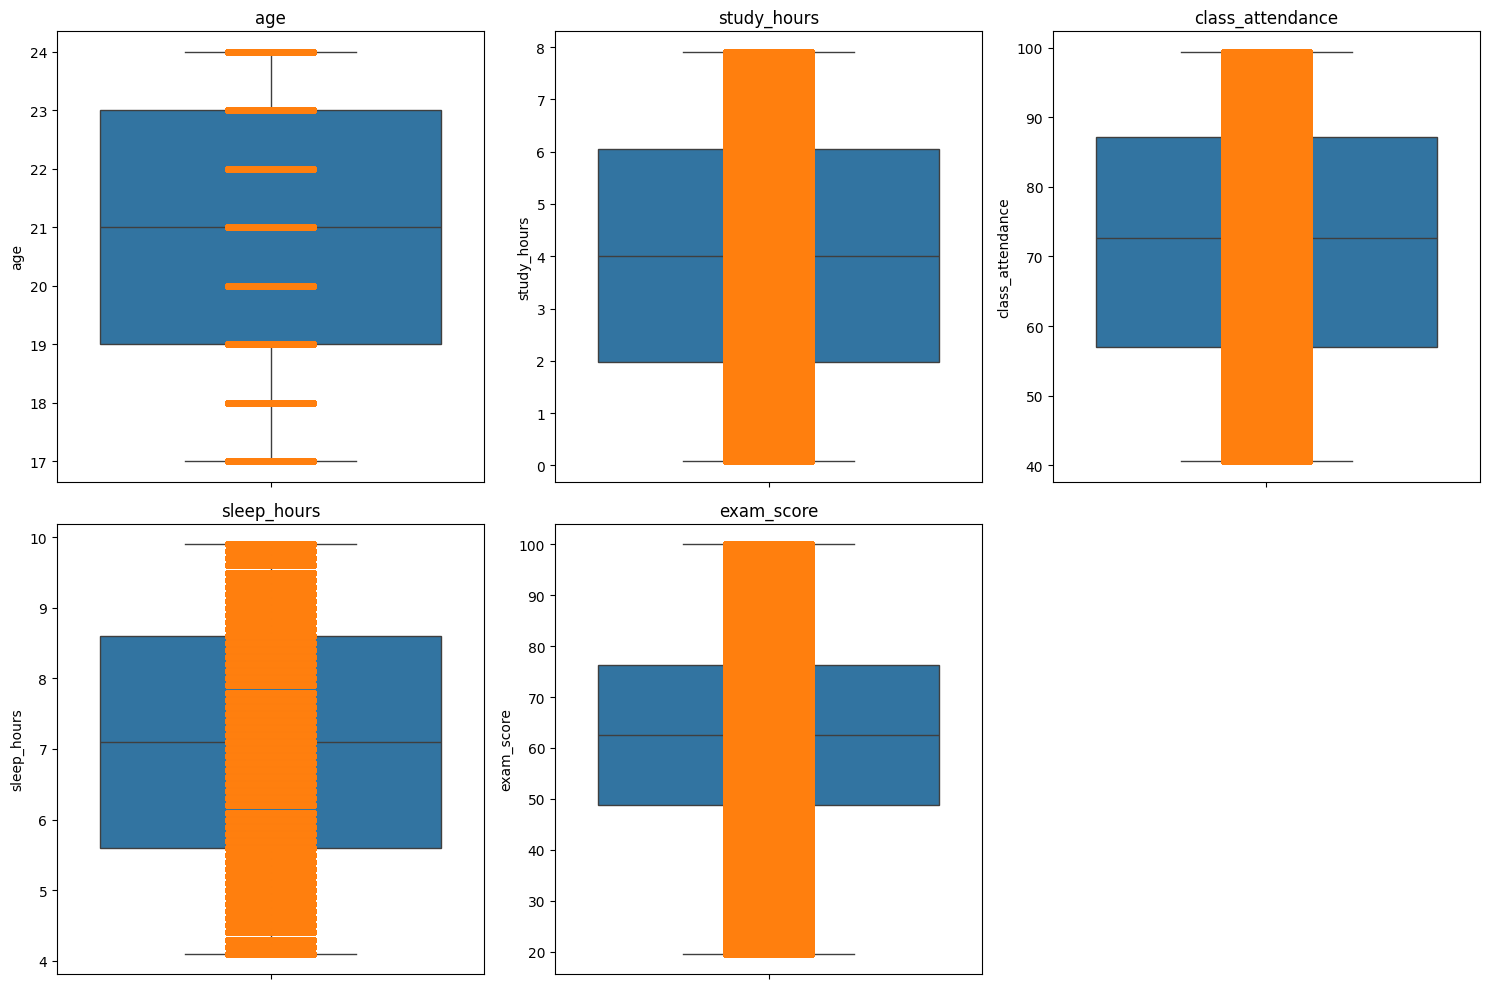

In [34]:
fig, axes = plt.subplots(n_rows, n_plot_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten() if n_cols > 1 else [axes]

for idx, col in enumerate(numeric_cols):
    sns.boxplot(
        data=df,
        y=col,
        ax=axes[idx]
    )
    sns.stripplot(
        data=df,
        y=col,
        ax=axes[idx]
    )
    axes[idx].set_title(col)

# Hide extra subplots if any
for idx in range(n_cols, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns
n_cols = len(numeric_cols)

# Calculate grid dimensions
n_rows = (n_cols + 2) // 3  # 3 columns per row
n_plot_cols = min(n_cols, 3)

fig, axes = plt.subplots(n_rows, n_plot_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten() if n_cols > 1 else [axes]

for idx, col in enumerate(numeric_cols):
    sns.violinplot(
        data=df,
        x=col,
    )
    axes[idx].set_title(col)

# Hide extra subplots if any
for idx in range(n_cols, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

In [35]:
corr = df.select_dtypes(include=["int64", "float64"]).corr()["exam_score"].drop("exam_score")

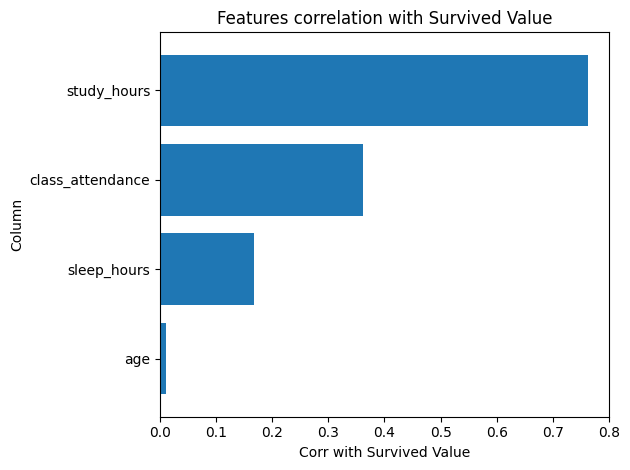

In [ ]:
corr.sort_values().plot(kind="barh", width=0.8)
plt.xlabel("Corr with Exam Score Value")
plt.ylabel("Column")
plt.title("Features correlation with Exam Score Value")
plt.tight_layout()
plt.show()

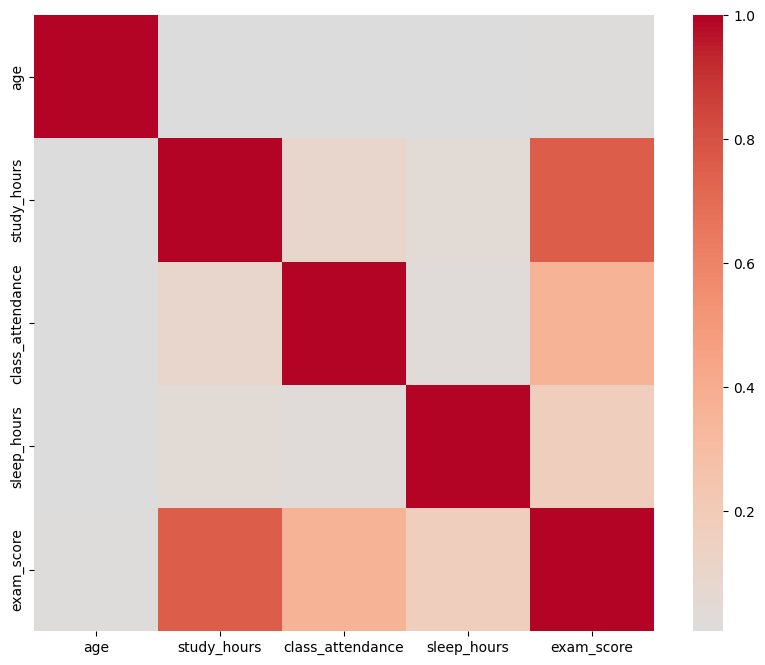

In [37]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    df.select_dtypes(exclude=["object", "category"]).corr(),
    cmap="coolwarm",
    center=0
)
plt.show()